In [ ]:
# ============================================================
# CELL 1: SETUP & IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Cấu hình font và style ──────────────────────────────
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FFFFFF',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

# Màu sắc nhất quán
COLOR_DX  = '#2563EB'   # Đông xuân - xanh dương
COLOR_HT  = '#F59E0B'   # Hè thu–Thu đông - cam
PALETTE13 = sns.color_palette('tab20', 13)

TINH_ORDER = [
    'An Giang','Kiên Giang','Đồng Tháp','Long An','Sóc Trăng',
    'Cần Thơ','Tiền Giang','Hậu Giang','Vĩnh Long','Trà Vinh',
    'Bạc Liêu','Cà Mau','Bến Tre'
]

In [ ]:
print("=" * 60)
print("EDA - SẢN LƯỢNG LÚA ĐBSCL 1995-2024")
print("=" * 60)

df = pd.read_csv('merged_dataset.csv')
df['nang_suat'] = (df['san_luong'] / df['dien_tich']).round(3)  # tấn/ha

print(f"\n📊 Dataset: {df.shape[0]} dòng × {df.shape[1]} cột")
print(f"   Giai đoạn: {df['nam'].min()} – {df['nam'].max()}")
print(f"   Tỉnh/thành: {df['tinh_thanh'].nunique()} tỉnh")
print(f"   Vụ mùa: {df['mua_vu'].unique().tolist()}")
print(f"   Missing: dien_tich={df['dien_tich'].isnull().sum()}, san_luong={df['san_luong'].isnull().sum()}")

print("\n📈 Thống kê mô tả:")
print(df[['dien_tich','san_luong','nang_suat',
          'tổng số giờ nắng','tổng lượng mưa',
          'độ ẩm trung bình','nhiệt độ trung bình']].describe().round(2).to_string())

EDA - SẢN LƯỢNG LÚA ĐBSCL 1995-2024

📊 Dataset: 780 dòng × 10 cột
   Giai đoạn: 1995 – 2024
   Tỉnh/thành: 13 tỉnh
   Vụ mùa: ['dong_xuan', 'he_thu-thu_dong']
   Missing: dien_tich=31, san_luong=31

📈 Thống kê mô tả:
       dien_tich  san_luong  nang_suat  tổng số giờ nắng  tổng lượng mưa  độ ẩm trung bình  nhiệt độ trung bình
count     749.00     749.00     749.00            780.00          780.00            780.00               780.00
mean      141.35     768.78       5.32           1778.73         1022.73             80.91                26.74
std        97.29     573.64       1.25            223.07          728.00              4.45                 0.59
min         0.40       0.20       0.04           1402.09           47.40             67.91                25.38
25%        61.10     346.80       4.36           1572.37          289.05             77.56                26.29
50%       129.80     618.50       5.34           1701.37          969.80             81.76                26.78

1. BẢNG THỐNG KÊ SỐ DÒNG BỊ THIẾU DỮ LIỆU THEO NĂM VÀ TỈNH
nam         1995  1996  1997  1998  1999  2000  2001  2002  2003  2007  2008  \
tinh_thanh                                                                     
An Giang       0     0     0     0     0     0     0     0     0     0     0   
Bạc Liêu       1     0     0     0     0     0     0     0     0     0     0   
Bến Tre        0     0     0     0     0     0     0     0     0     0     0   
Cà Mau         1     0     0     0     0     0     0     0     0     1     1   
Cần Thơ        0     0     0     0     0     0     0     0     0     0     0   
Hậu Giang      2     2     2     2     2     2     2     2     2     0     0   
Kiên Giang     0     0     0     0     0     0     0     0     0     0     0   
Long An        0     0     0     0     0     0     0     0     0     0     0   
Sóc Trăng      0     0     0     0     0     0     0     0     0     0     0   
Tiền Giang     0     0     0     0     0     0     0     0   

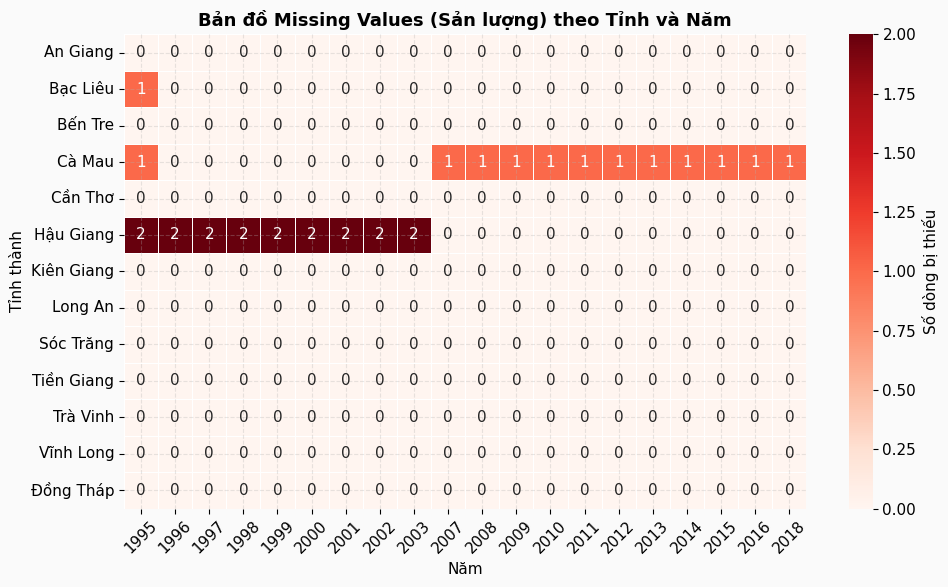


2. CHI TIẾT CÁC DÒNG BỊ THIẾU DỮ LIỆU (Diện tích hoặc Sản lượng)
      nam tinh_thanh           mua_vu  dien_tich  san_luong
2    1995   Bạc Liêu        dong_xuan        NaN        NaN
6    1995     Cà Mau        dong_xuan        NaN        NaN
10   1995  Hậu Giang        dong_xuan        NaN        NaN
11   1995  Hậu Giang  he_thu-thu_dong        NaN        NaN
36   1996  Hậu Giang        dong_xuan        NaN        NaN
37   1996  Hậu Giang  he_thu-thu_dong        NaN        NaN
62   1997  Hậu Giang        dong_xuan        NaN        NaN
63   1997  Hậu Giang  he_thu-thu_dong        NaN        NaN
88   1998  Hậu Giang        dong_xuan        NaN        NaN
89   1998  Hậu Giang  he_thu-thu_dong        NaN        NaN
114  1999  Hậu Giang        dong_xuan        NaN        NaN
115  1999  Hậu Giang  he_thu-thu_dong        NaN        NaN
140  2000  Hậu Giang        dong_xuan        NaN        NaN
141  2000  Hậu Giang  he_thu-thu_dong        NaN        NaN
166  2001  Hậu Giang        dong_x

In [ ]:
# 1. Đọc dữ liệu
df = pd.read_csv('merged_dataset.csv')

# 2. Tạo Pivot Table đếm số lượng missing value của cột 'san_luong' (hoặc 'dien_tich')
# Hàng (index) là Tỉnh thành, Cột (columns) là Năm
missing_pivot = df.pivot_table(
    index='tinh_thanh',
    columns='nam',
    values='san_luong',
    aggfunc=lambda x: x.isnull().sum()
)

# Lọc ra chỉ những năm có ít nhất 1 giá trị bị thiếu để bảng gọn hơn
missing_filtered = missing_pivot.loc[:, (missing_pivot > 0).any(axis=0)]

print("=" * 60)
print("1. BẢNG THỐNG KÊ SỐ DÒNG BỊ THIẾU DỮ LIỆU THEO NĂM VÀ TỈNH")
print("=" * 60)
if missing_filtered.empty:
    print("✅ Dữ liệu hoàn chỉnh, không có giá trị nào bị thiếu!")
else:
    print(missing_filtered.astype('Int64')) # Ép kiểu Int để in ra số nguyên cho đẹp

# 3. Trực quan hóa bằng Heatmap
if not missing_filtered.empty:
    plt.figure(figsize=(10, 6))
    sns.heatmap(missing_filtered, cmap='Reds', annot=True, fmt='.0f',
                linewidths=0.5, cbar_kws={'label': 'Số dòng bị thiếu'})
    plt.title('Bản đồ Missing Values (Sản lượng) theo Tỉnh và Năm', fontweight='bold')
    plt.xlabel('Năm')
    plt.ylabel('Tỉnh thành')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 4. Liệt kê chi tiết các dòng bị thiếu
print("\n" + "=" * 60)
print("2. CHI TIẾT CÁC DÒNG BỊ THIẾU DỮ LIỆU (Diện tích hoặc Sản lượng)")
print("=" * 60)
missing_rows = df[df['san_luong'].isnull() | df['dien_tich'].isnull()]

if missing_rows.empty:
    print("✅ Không có dòng nào bị thiếu!")
else:
    # Chỉ in ra các cột quan trọng để dễ nhìn
    cols_to_show = ['nam', 'tinh_thanh', 'mua_vu', 'dien_tich', 'san_luong']
    print(missing_rows[cols_to_show].sort_values(by=['nam', 'tinh_thanh']))
    print(f"\nTổng cộng: {len(missing_rows)} dòng bị thiếu.")

Vì san_luong (tổng sản lượng) phụ thuộc rất lớn vào dien_tich (diện tích gieo trồng), nên để đánh giá chính xác tác động của khí hậu, tính thêm biến nang_suat (Năng suất = Sản lượng / Diện tích).

Năng suất theo từng vụ là khác nhau + với đó là theo năm tăng lên thì diện tích trồng lúa cũng có biến động nên là các biến như năm, sản lượng, diện tích nó sẽ biến tăng qua các thời kì nên năm cũng được đưa vào.

In [ ]:

df['nang_suat'] = (df['san_luong'] / df['dien_tich']).round(3)

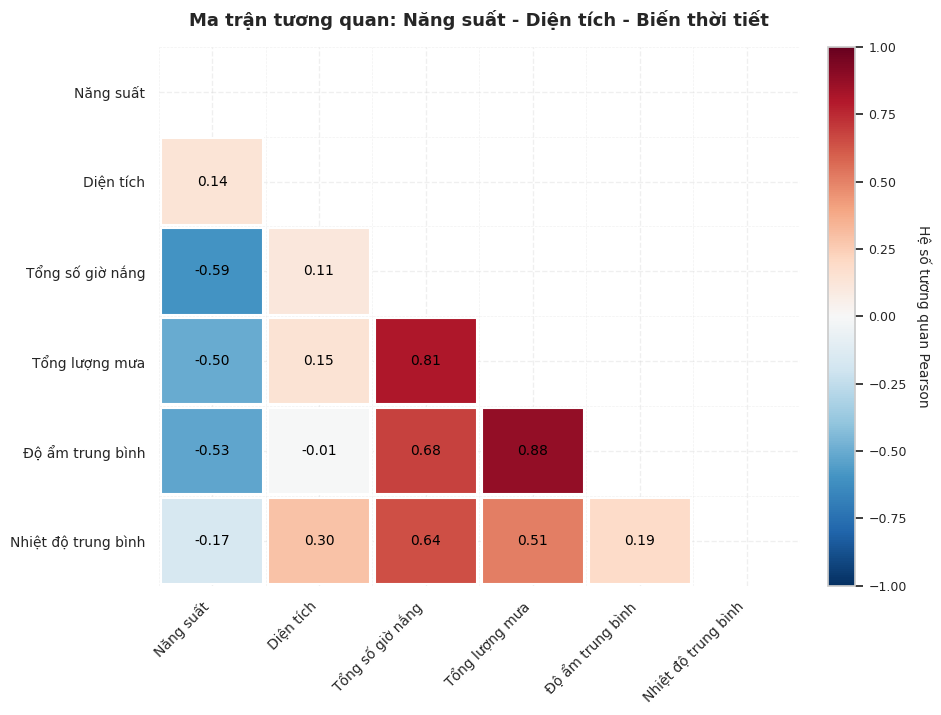

In [ ]:
# Chọn các cột cần thiết và đổi tên tiếng Việt
cols = {
    'nang_suat': 'Năng suất',
    'dien_tich': 'Diện tích',
    'tổng số giờ nắng': 'Tổng số giờ nắng',
    'tổng lượng mưa': 'Tổng lượng mưa',
    'độ ẩm trung bình': 'Độ ẩm trung bình',
    'nhiệt độ trung bình': 'Nhiệt độ trung bình',
}

data = df[list(cols.keys())].rename(columns=cols).dropna()

# Tính ma trận tương quan Pearson
corr = data.corr(method='pearson')

# Lấy tam giác dưới (lower triangle, không kể đường chéo)
mask = np.triu(np.ones_like(corr, dtype=bool), k=0)  # mask phần trên + đường chéo
corr_lower = corr.copy()
corr_lower[mask] = np.nan

labels = list(corr.columns)
n = len(labels)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Colormap đỏ-trắng-xanh
cmap = plt.cm.RdBu_r
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

# Vẽ từng ô
for i in range(n):
    for j in range(n):
        if not mask[i, j]:
            val = corr_lower.iloc[i, j]
            color = cmap(norm(val))
            rect = mpatches.FancyBboxPatch(
                (j - 0.48, i - 0.48), 0.96, 0.96,
                boxstyle="square,pad=0",
                facecolor=color, edgecolor='white', linewidth=1.5
            )
            ax.add_patch(rect)
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=10, color='black', fontweight='normal')

# Trục
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(-0.5, n - 0.5)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(labels, fontsize=10)
ax.invert_yaxis()

# Gridlines
ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which='minor', color='lightgray', linestyle='--', linewidth=0.5)
ax.tick_params(which='minor', bottom=False, left=False)

# Ẩn viền
for spine in ax.spines.values():
    spine.set_visible(False)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.04)
cbar.set_label('Hệ số tương quan Pearson', fontsize=10, rotation=270, labelpad=18)
cbar.ax.tick_params(labelsize=9)

ax.set_title('Ma trận tương quan: Năng suất - Diện tích - Biến thời tiết',
             fontsize=13, fontweight='bold', pad=15)

plt.show()

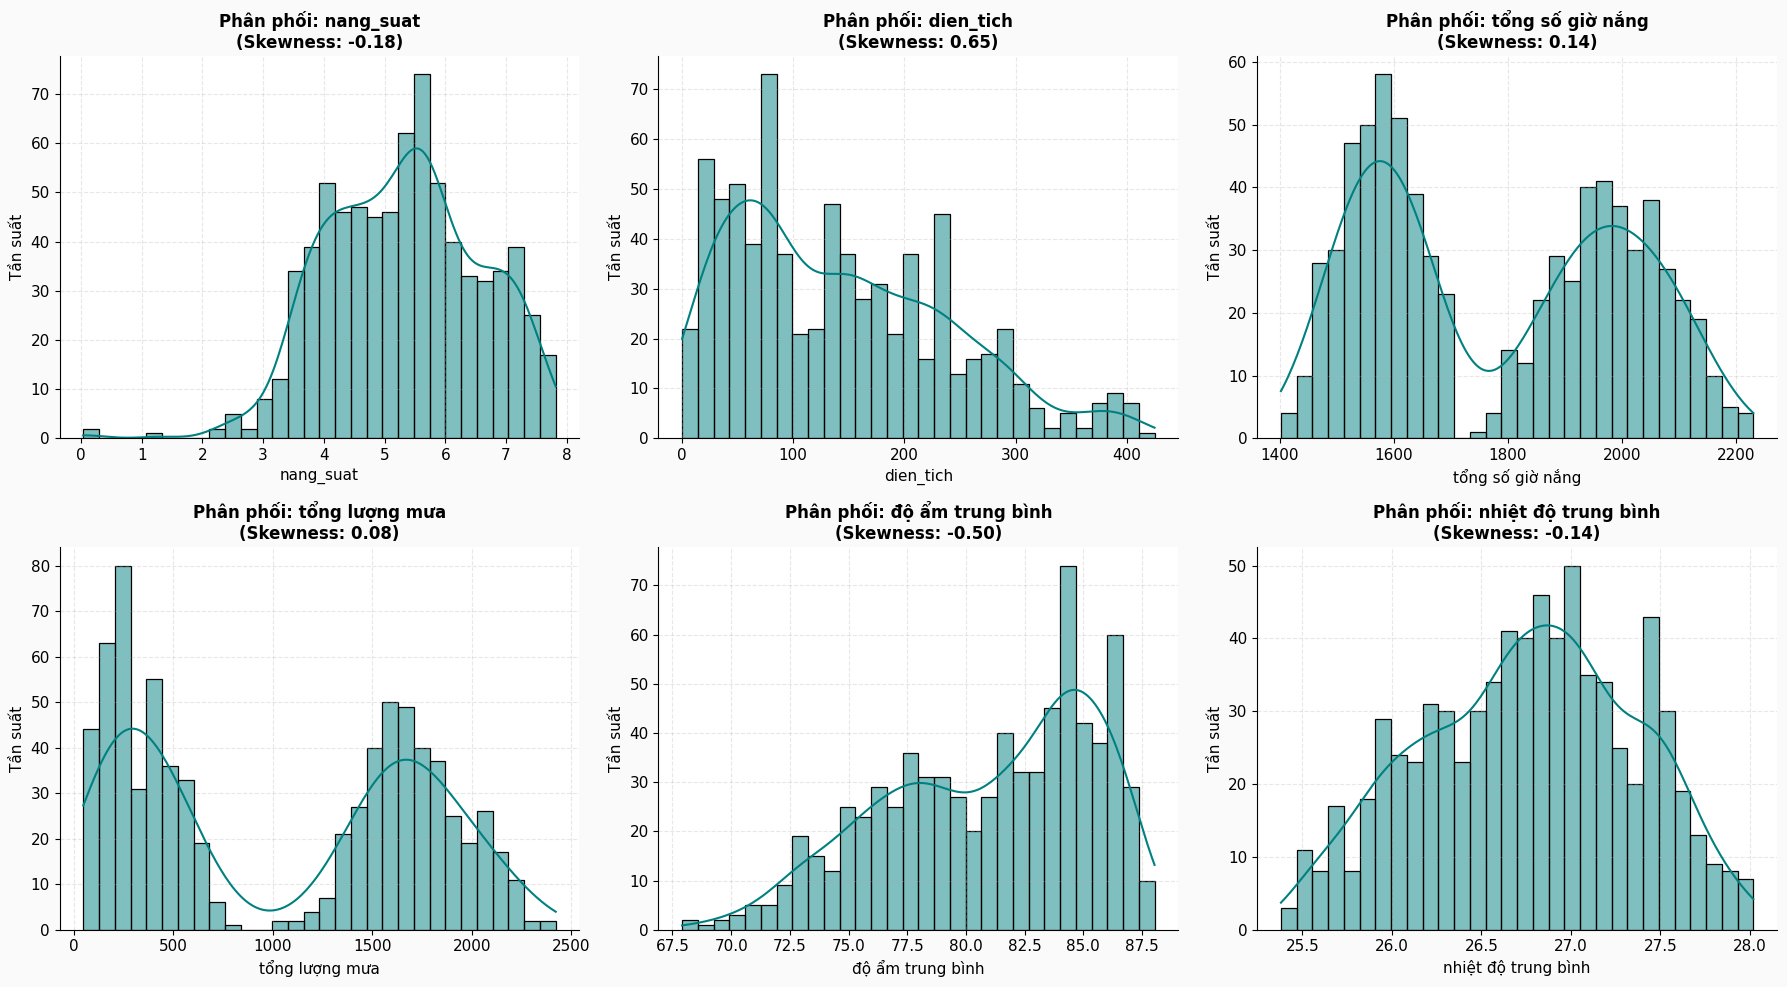

In [ ]:
# 2. Tạo bản sao bỏ qua NaN để vẽ
df_plot = df.dropna(subset=['dien_tich', 'san_luong']).copy()
df_plot['nang_suat'] = df_plot['san_luong'] / df_plot['dien_tich']

# 3. Thêm 'dien_tich' vào danh sách (Tổng cộng 6 biến)
numerical_cols = ['nang_suat', 'dien_tich', 'tổng số giờ nắng', 'tổng lượng mưa', 'độ ẩm trung bình', 'nhiệt độ trung bình']

# 4. Tạo khung hình (figure) 2 hàng x 3 cột (Vừa khớp 6 ô)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

# 5. Lặp qua từng biến để vẽ
for i, col in enumerate(numerical_cols):
    skew_val = df_plot[col].skew()

    # Vẽ Histogram kèm đường KDE
    sns.histplot(data=df_plot, x=col, kde=True, ax=axes[i], color='teal', bins=30)

    # Tiêu đề có chứa giá trị Skewness
    axes[i].set_title(f"Phân phối: {col}\n(Skewness: {skew_val:.2f})", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Tần suất")

# Căn chỉnh lại khoảng cách giữa các biểu đồ
plt.tight_layout()

# Hiển thị đồ thị
plt.show()

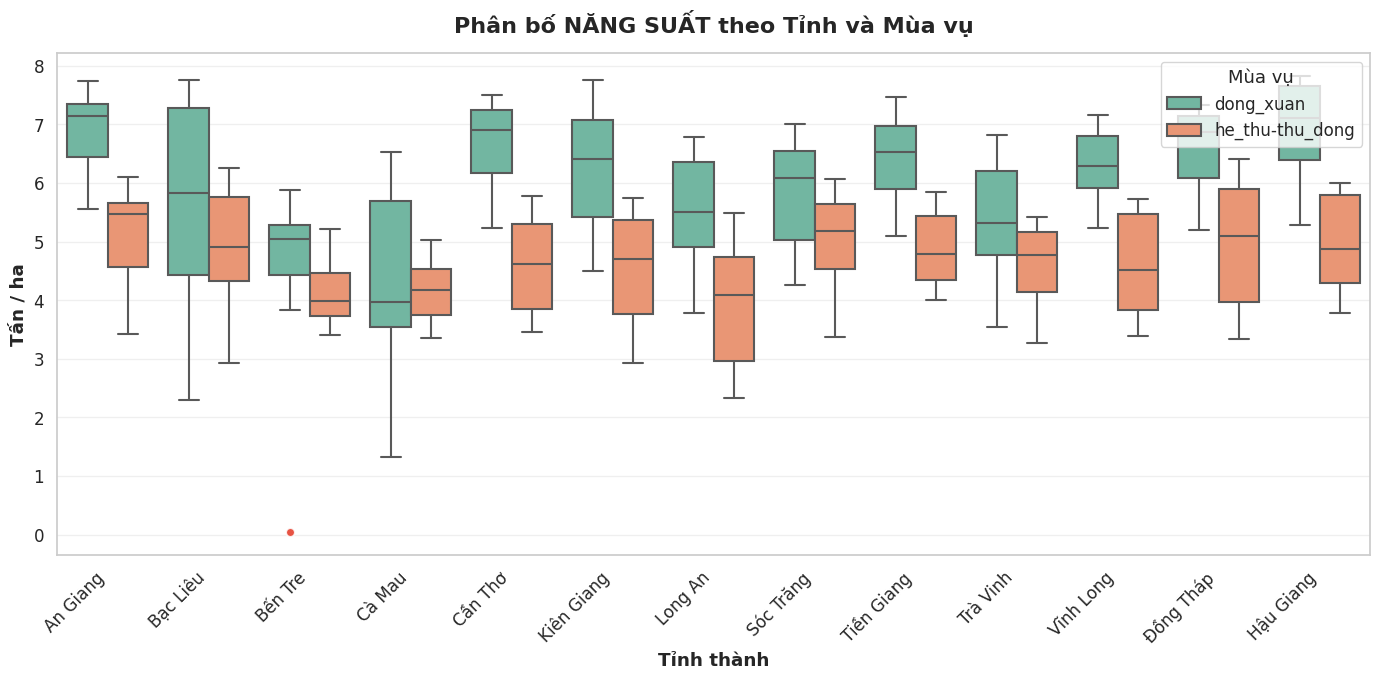

In [ ]:
# 1. Chuẩn bị dữ liệu
df_plot = df.dropna(subset=['dien_tich', 'san_luong']).copy()
df_plot['nang_suat'] = df_plot['san_luong'] / df_plot['dien_tich']

# Thiết lập giao diện nền: Trắng có lưới mờ tinh tế
sns.set_theme(style="whitegrid", font_scale=1.1)

# 2. Vẽ biểu đồ NĂNG SUẤT
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_plot,
    x='tinh_thanh',
    y='nang_suat',
    hue='mua_vu',
    palette="Set2", # Màu pastel nhẹ nhàng, thanh lịch
    linewidth=1.5,
    fliersize=6,
    flierprops={'marker': 'o', 'markerfacecolor': '#e74c3c', 'markeredgecolor': 'white', 'alpha': 0.8}
)

plt.title('Phân bố NĂNG SUẤT theo Tỉnh và Mùa vụ', fontweight='bold', fontsize=16, pad=15)
plt.xlabel('Tỉnh thành', fontweight='bold')
plt.ylabel('Tấn / ha', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Mùa vụ', title_fontsize='13', loc='upper right')

plt.tight_layout()
plt.show()

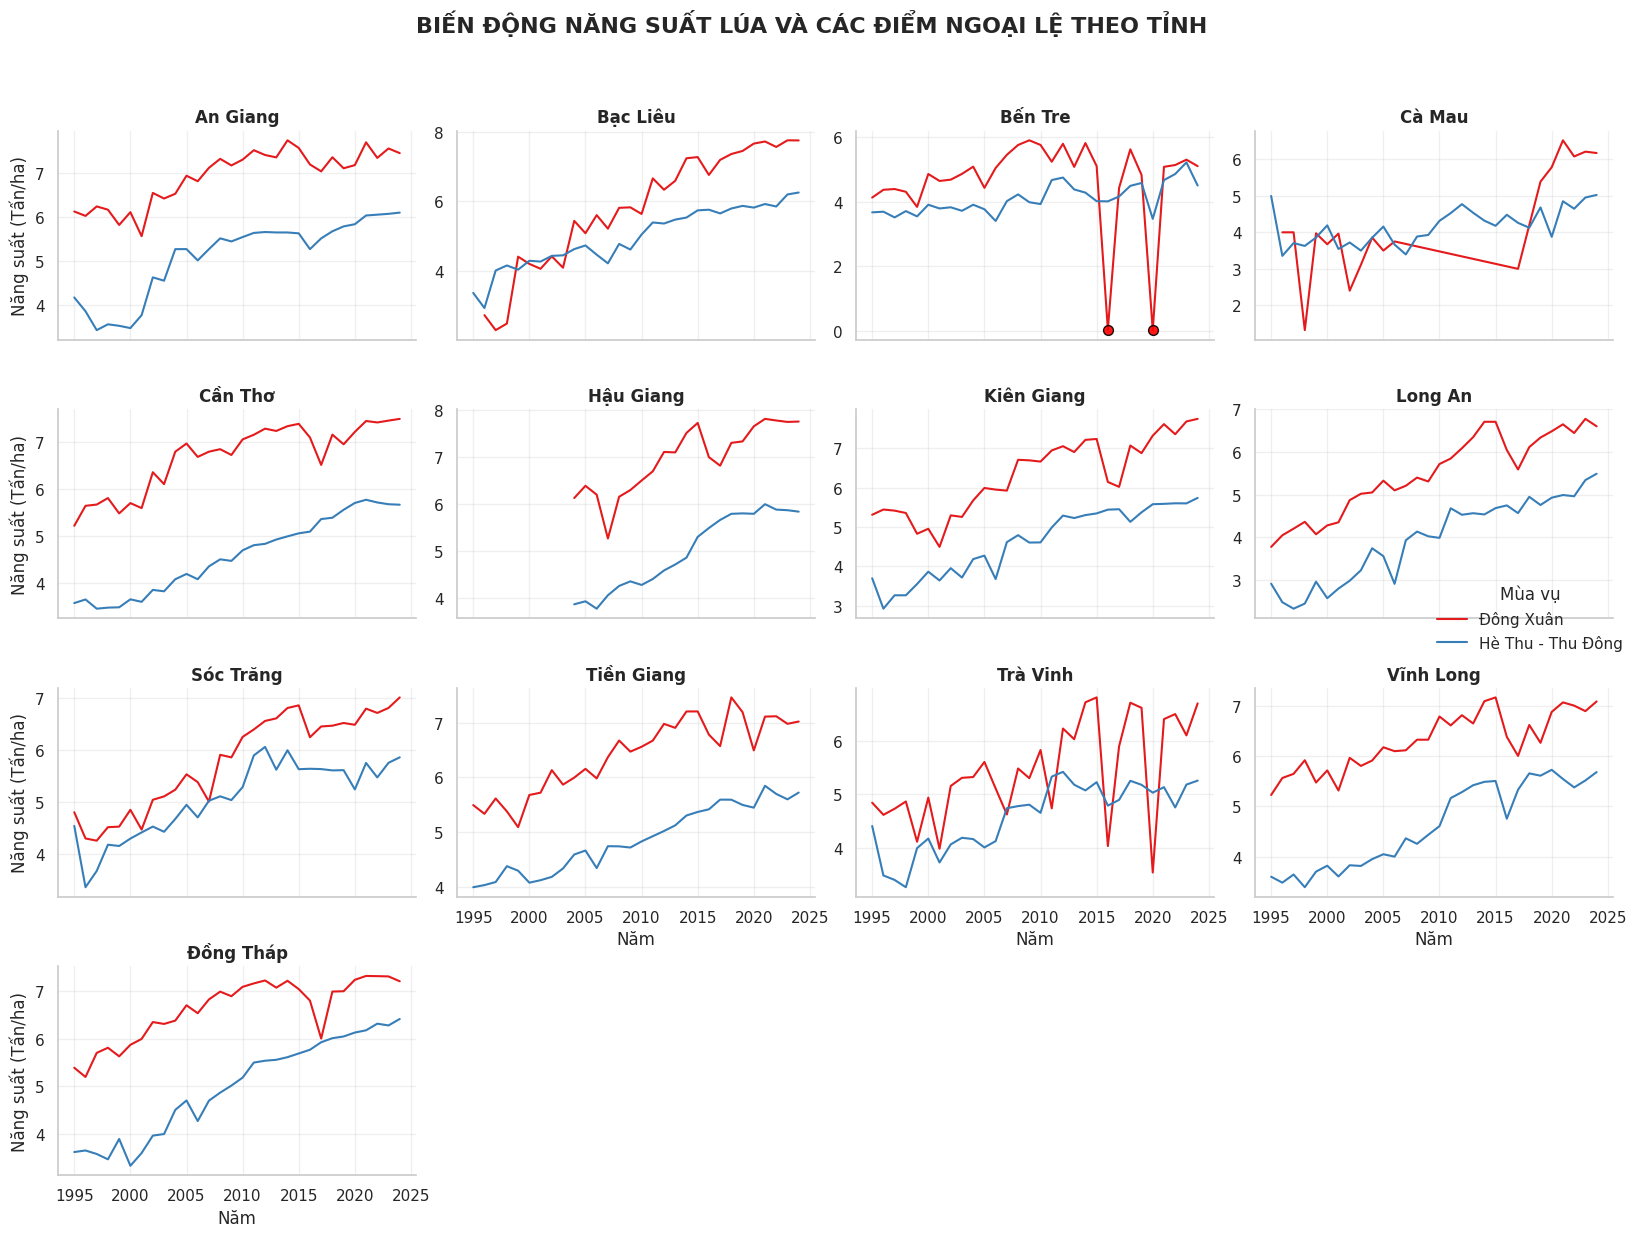

In [ ]:
# Tính Năng suất (tấn/ha) = Sản lượng (nghìn tấn) / Diện tích (nghìn ha)
df['nang_suat'] = df['san_luong'] / df['dien_tich']

# 2. Hàm tìm Outlier bằng IQR
def detect_outliers(group):
    # Loại bỏ các dòng bị rỗng năng suất (do chia cho 0 hoặc thiếu dữ liệu)
    valid_group = group.dropna(subset=['nang_suat'])
    if valid_group.empty: return valid_group

    Q1 = valid_group['nang_suat'].quantile(0.25)
    Q3 = valid_group['nang_suat'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return valid_group[(valid_group['nang_suat'] < lower_bound) | (valid_group['nang_suat'] > upper_bound)]

# Áp dụng hàm để lấy dataframe chứa các điểm Outlier
outliers = df.groupby(['tinh_thanh', 'mua_vu']).apply(detect_outliers).reset_index(drop=True)

# Format lại tên mùa vụ
df['Mùa vụ'] = df['mua_vu'].map({'dong_xuan': 'Đông Xuân', 'he_thu-thu_dong': 'Hè Thu - Thu Đông'})
outliers['Mùa vụ'] = outliers['mua_vu'].map({'dong_xuan': 'Đông Xuân', 'he_thu-thu_dong': 'Hè Thu - Thu Đông'})

# 3. Thiết lập style biểu đồ
sns.set_theme(style="whitegrid")

# 4. Vẽ FacetGrid (Lưới đồ thị)
g = sns.relplot(
    data=df,
    x="nam", y="nang_suat",
    hue="Mùa vụ", col="tinh_thanh", col_wrap=4,
    kind="line", height=3, aspect=1.2,
    facet_kws={'sharey': False, 'sharex': True},
    palette="Set1", linewidth=1.5
)

# 5. Vẽ thêm chấm đỏ ngoại lệ
for province, ax in g.axes_dict.items():
    prov_outliers = outliers[outliers['tinh_thanh'] == province]
    if not prov_outliers.empty:
        ax.scatter(prov_outliers['nam'], prov_outliers['nang_suat'],
                   color='red', edgecolor='black', s=50, zorder=5, alpha=0.9)

# 6. Tùy chỉnh nhãn và tiêu đề chung
g.set_titles(col_template="{col_name}", fontweight='bold')
g.set_axis_labels("Năm", "Năng suất (Tấn/ha)")
g.fig.suptitle('BIẾN ĐỘNG NĂNG SUẤT LÚA VÀ CÁC ĐIỂM NGOẠI LỆ THEO TỈNH',
               y=1.03, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

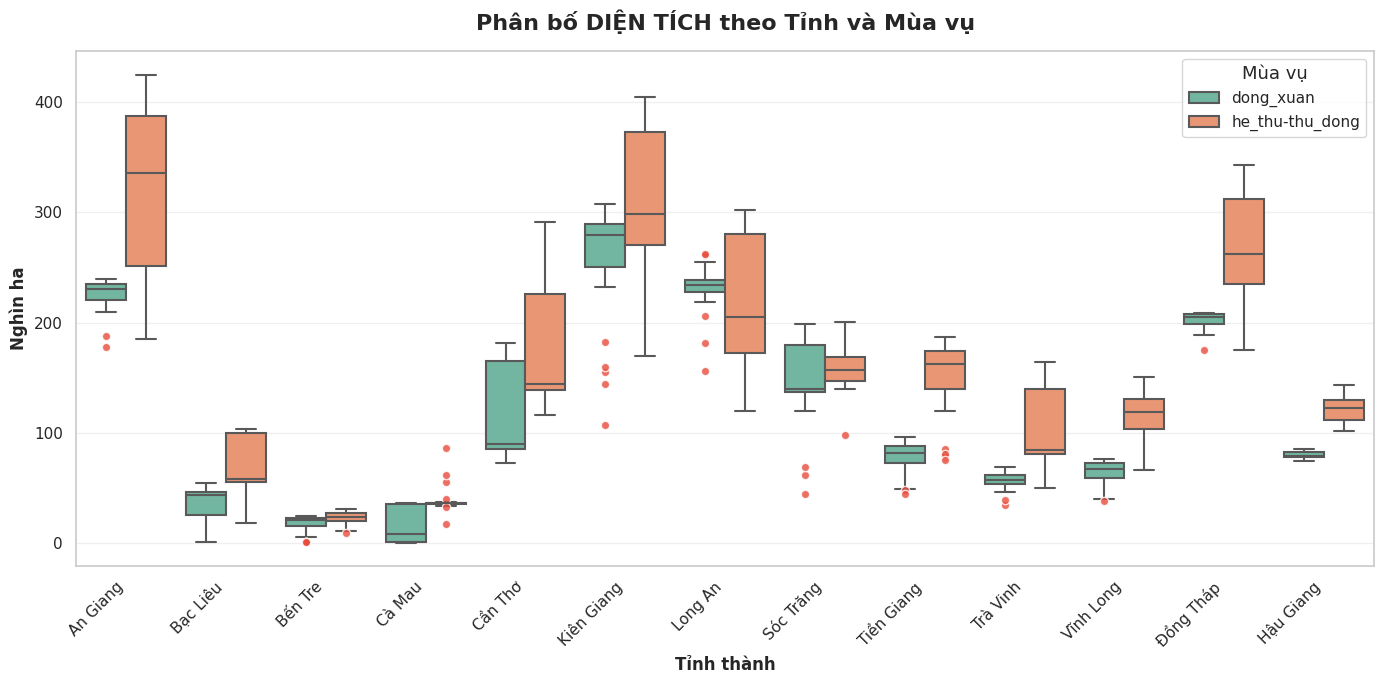

In [ ]:
# 3. Vẽ biểu đồ DIỆN TÍCH
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_plot,
    x='tinh_thanh',
    y='dien_tich',
    hue='mua_vu',
    palette="Set2", # Tone màu rực rỡ, nổi bật
    linewidth=1.5,
    fliersize=6,
    flierprops={'marker': 'o', 'markerfacecolor': '#e74c3c', 'markeredgecolor': 'white', 'alpha': 0.8}
)

plt.title('Phân bố DIỆN TÍCH theo Tỉnh và Mùa vụ', fontweight='bold', fontsize=16, pad=15)
plt.xlabel('Tỉnh thành', fontweight='bold')
plt.ylabel('Nghìn ha', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Mùa vụ', title_fontsize='13', loc='upper right')

plt.tight_layout()
plt.show()

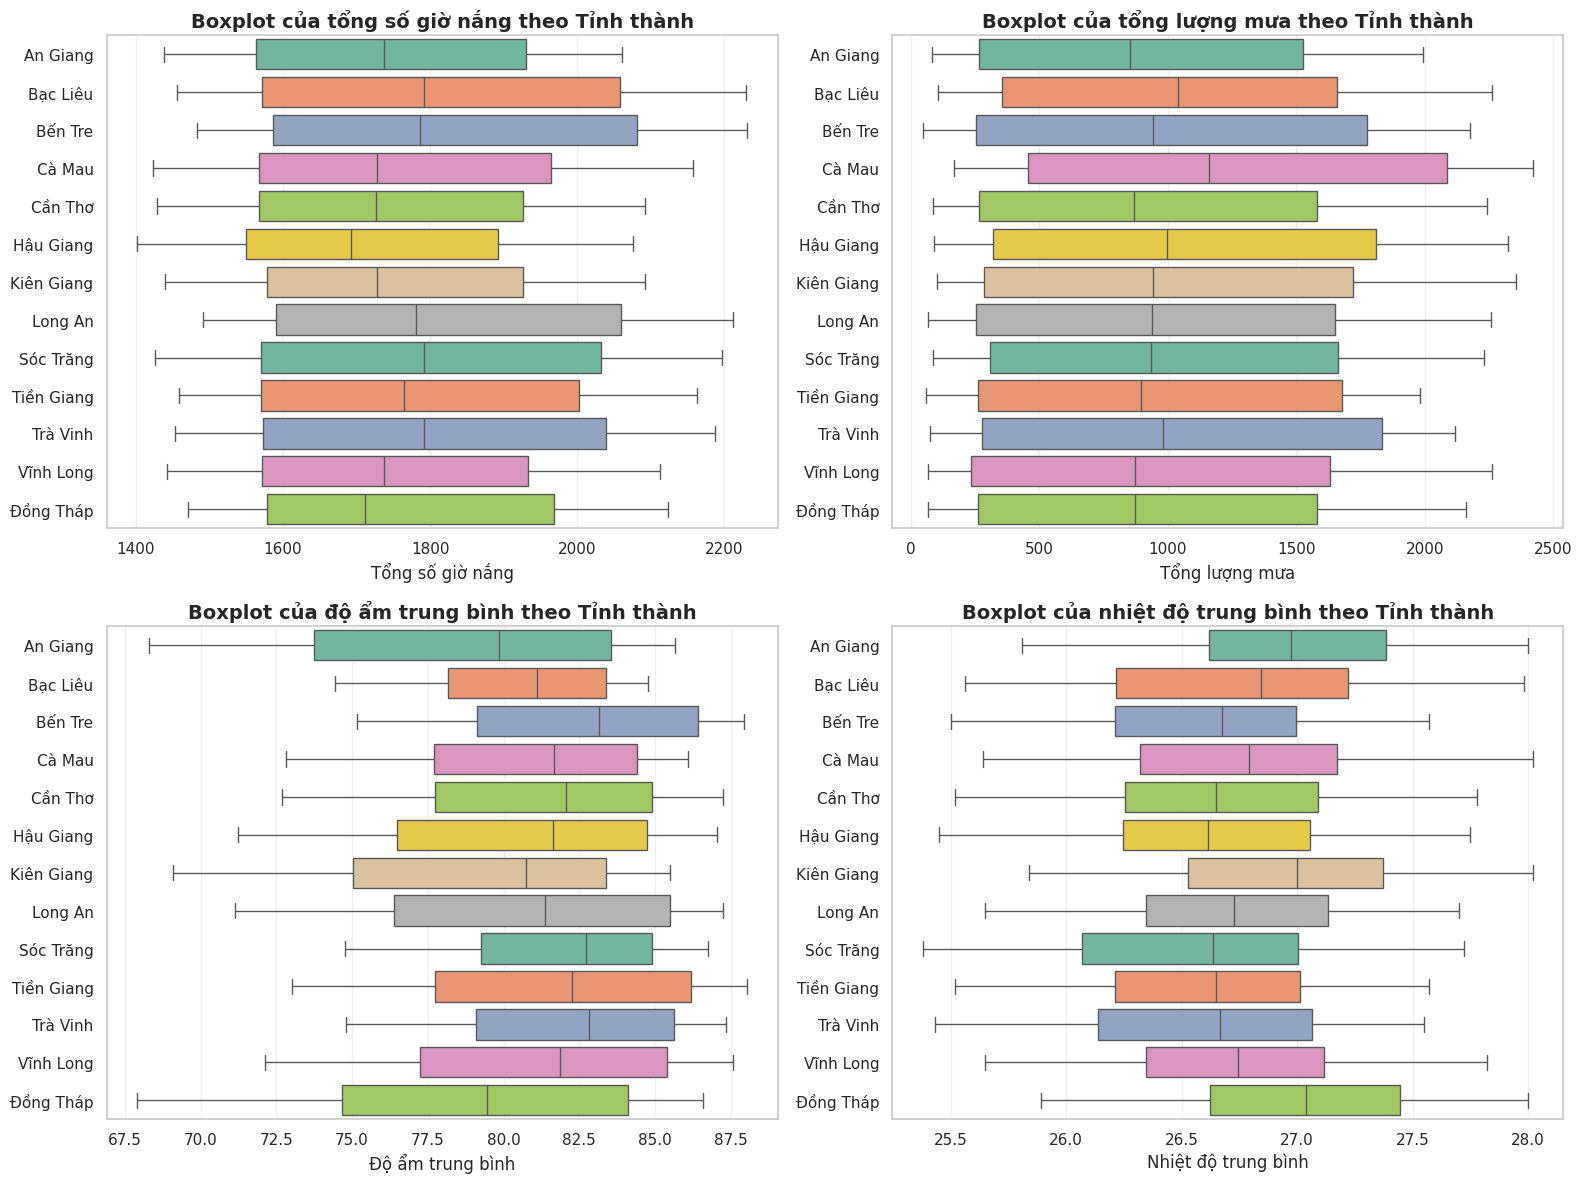

In [ ]:
# 2. Danh sách các biến thời tiết cần vẽ
weather_cols = [
    'tổng số giờ nắng',
    'tổng lượng mưa',
    'độ ẩm trung bình',
    'nhiệt độ trung bình'
]

# 3. Khởi tạo biểu đồ với kích thước 2x2 (4 ô)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

# 4. Dùng vòng lặp để vẽ boxplot cho từng biến
for i, col in enumerate(weather_cols):
    sns.boxplot(
        data=df,
        y='tinh_thanh',  # Đặt tỉnh thành ở trục y để dễ đọc tên
        x=col,           # Trục x là giá trị của biến thời tiết
        ax=axes[i],
        palette='Set2'
    )
    axes[i].set_title(f'Boxplot của {col} theo Tỉnh thành', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('')  # Ẩn chữ 'tinh_thanh' ở trục Y cho đỡ rối
    axes[i].set_xlabel(col.capitalize(), fontsize=12)

# 5. Căn chỉnh khoảng cách và lưu/hiển thị biểu đồ
plt.tight_layout()
plt.savefig('weather_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

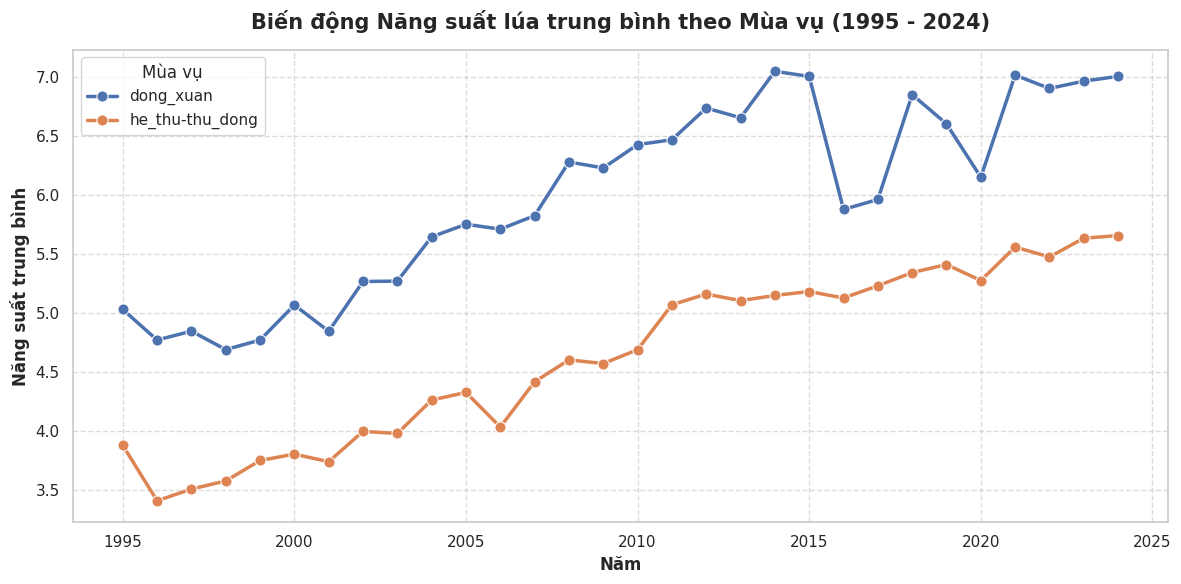

In [ ]:
# Cell 1: Phân tích xu hướng năng suất theo mùa vụ
import matplotlib.pyplot as plt
import seaborn as sns

# Gom nhóm tính trung bình năng suất theo năm và mùa vụ
df_season = df.groupby(['nam', 'mua_vu'])['nang_suat'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_season, x='nam', y='nang_suat', hue='mua_vu',
             marker='o', linewidth=2.5, markersize=8)

# Định dạng biểu đồ
plt.title('Biến động Năng suất lúa trung bình theo Mùa vụ (1995 - 2024)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Năm', fontsize=12, fontweight='bold')
plt.ylabel('Năng suất trung bình', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Mùa vụ', title_fontsize='12', fontsize='11', loc='best')

# Tránh bị cắt chữ khi lưu ảnh
plt.tight_layout()
plt.show()

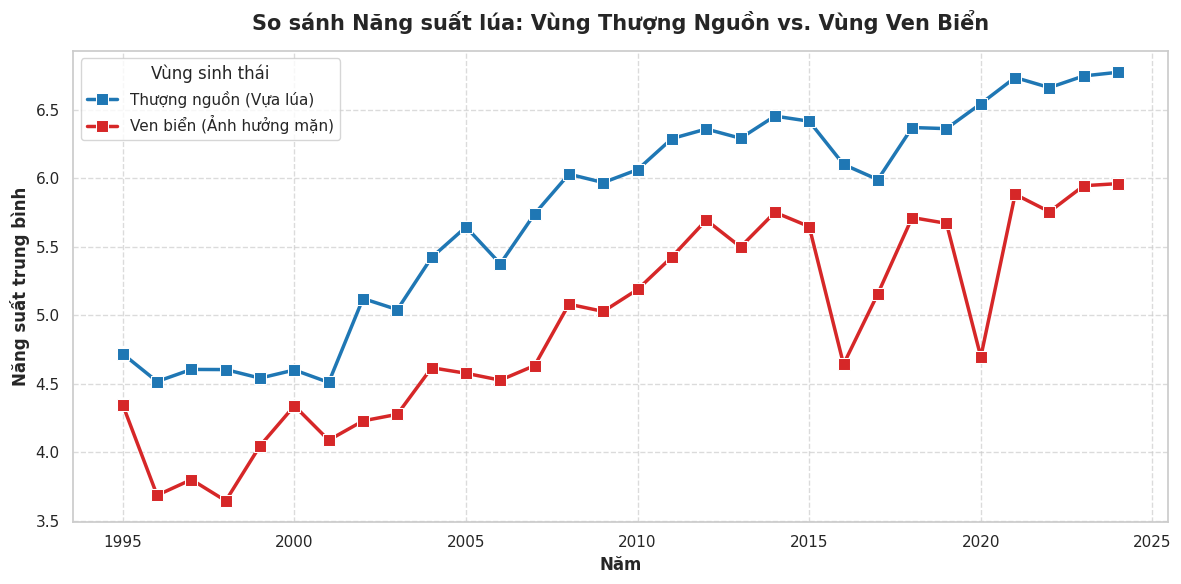

In [ ]:
# Cell 2: Phân tích sự dịch chuyển theo Vùng sinh thái
# Phân loại nhóm tỉnh dựa trên địa lý và rủi ro mặn
thuong_nguon = ['An Giang', 'Đồng Tháp', 'Kiên Giang'] # Nhóm vựa lúa ổn định
ven_bien = ['Bến Tre', 'Trà Vinh', 'Sóc Trăng', 'Bạc Liêu', 'Cà Mau'] # Nhóm rủi ro hạn mặn

def phan_vung(tinh):
    if tinh in thuong_nguon:
        return 'Thượng nguồn (Vựa lúa)'
    elif tinh in ven_bien:
        return 'Ven biển (Ảnh hưởng mặn)'
    else:
        return 'Trung tâm/Khác'

# Tạo cột Vùng sinh thái mới
df['Vùng sinh thái'] = df['tinh_thanh'].apply(phan_vung)

# Chỉ lọc lấy 2 nhóm chính để so sánh sự đối lập
df_regions = df[df['Vùng sinh thái'] != 'Trung tâm/Khác']
df_trend = df_regions.groupby(['nam', 'Vùng sinh thái'])['nang_suat'].mean().reset_index()

plt.figure(figsize=(12, 6))
# Sử dụng màu xanh cho thượng nguồn (nước ngọt) và đỏ cam cho ven biển (nguy cơ)
sns.lineplot(data=df_trend, x='nam', y='nang_suat', hue='Vùng sinh thái',
             marker='s', palette=['#1f77b4', '#d62728'], linewidth=2.5, markersize=8)

plt.title('So sánh Năng suất lúa: Vùng Thượng Nguồn vs. Vùng Ven Biển', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Năm', fontsize=12, fontweight='bold')
plt.ylabel('Năng suất trung bình', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Vùng sinh thái', title_fontsize='12', fontsize='11', loc='best')

plt.tight_layout()
plt.show()

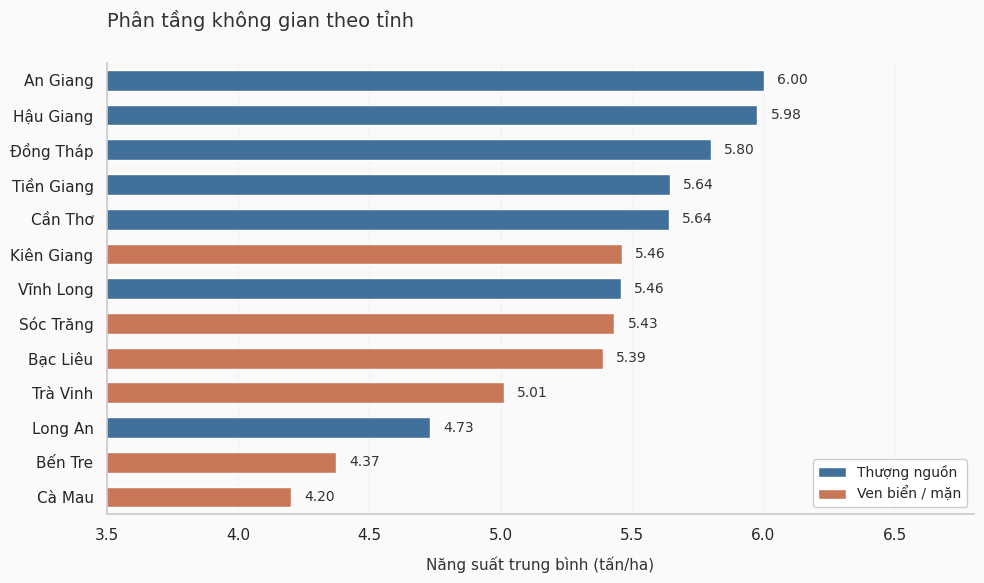

In [ ]:
# 1. Tính năng suất trung bình theo từng tỉnh
# Lưu ý: Thay 'Năng suất' bằng tên cột của bạn (ví dụ: 'nang_suat' nếu đơn vị là tạ/ha, bạn có thể chia 10 để ra tấn/ha)
df_mean = df.groupby('tinh_thanh')['nang_suat'].mean().reset_index()

# 2. Phân loại vùng sinh thái theo đúng chuẩn biểu đồ của bạn
ven_bien_man = ['Kiên Giang', 'Sóc Trăng', 'Bạc Liêu', 'Trà Vinh', 'Bến Tre', 'Cà Mau']

def phan_vung_ban_do(tinh):
    if tinh in ven_bien_man:
        return 'Ven biển / mặn'
    else:
        return 'Thượng nguồn'

df_mean['Zone'] = df_mean['tinh_thanh'].apply(phan_vung_ban_do)

# 3. Sắp xếp dữ liệu từ cao xuống thấp
df_mean = df_mean.sort_values(by='nang_suat', ascending=False)

# 4. Bắt đầu vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#fafafa')
ax.set_facecolor('#fafafa')

# Mã màu giống hệt hình (Xanh dương đậm và Cam ngói)
palette_colors = {'Thượng nguồn': '#3271a9', 'Ven biển / mặn': '#dc6e46'}

# Vẽ Barplot nằm ngang
sns.barplot(
    data=df_mean,
    x='nang_suat',
    y='tinh_thanh',
    hue='Zone',
    palette=palette_colors,
    dodge=False, # Không tách bar khi dùng hue
    ax=ax,
    width=0.6 # Độ dày của thanh
)

# 5. Thêm text giá trị ở đuôi mỗi thanh
for p in ax.patches:
    width = p.get_width()
    if pd.isna(width) or width == 0:
        continue
    ax.text(width + 0.05,
            p.get_y() + p.get_height() / 2,
            f'{width:.2f}',
            ha='left', va='center', fontsize=10, color='#333333')

# 6. Tinh chỉnh khung hình và trục (Giới hạn trục X từ 3.5 để nhấn mạnh độ lệch)
plt.xlim(3.5, df_mean['nang_suat'].max() + 0.8)

# Tiêu đề chính và Tiêu đề phụ (Subtitle)
plt.text(0, 1.08, 'Phân tầng không gian theo tỉnh', transform=ax.transAxes, fontsize=14, color='#333333')


# Xóa bỏ các viền không cần thiết cho gọn mắt
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Thêm lưới dọc mờ
plt.grid(axis='x', linestyle='-', alpha=0.15, color='#cccccc')

# Đặt lại nhãn trục
plt.xlabel('Năng suất trung bình (tấn/ha)', fontsize=11, color='#333333', labelpad=10)
plt.ylabel('') # Bỏ tên trục Y

# Định dạng Legend góc dưới bên phải
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, loc='lower right', fontsize=10, framealpha=1, edgecolor='#cccccc')

plt.tight_layout()
plt.show()

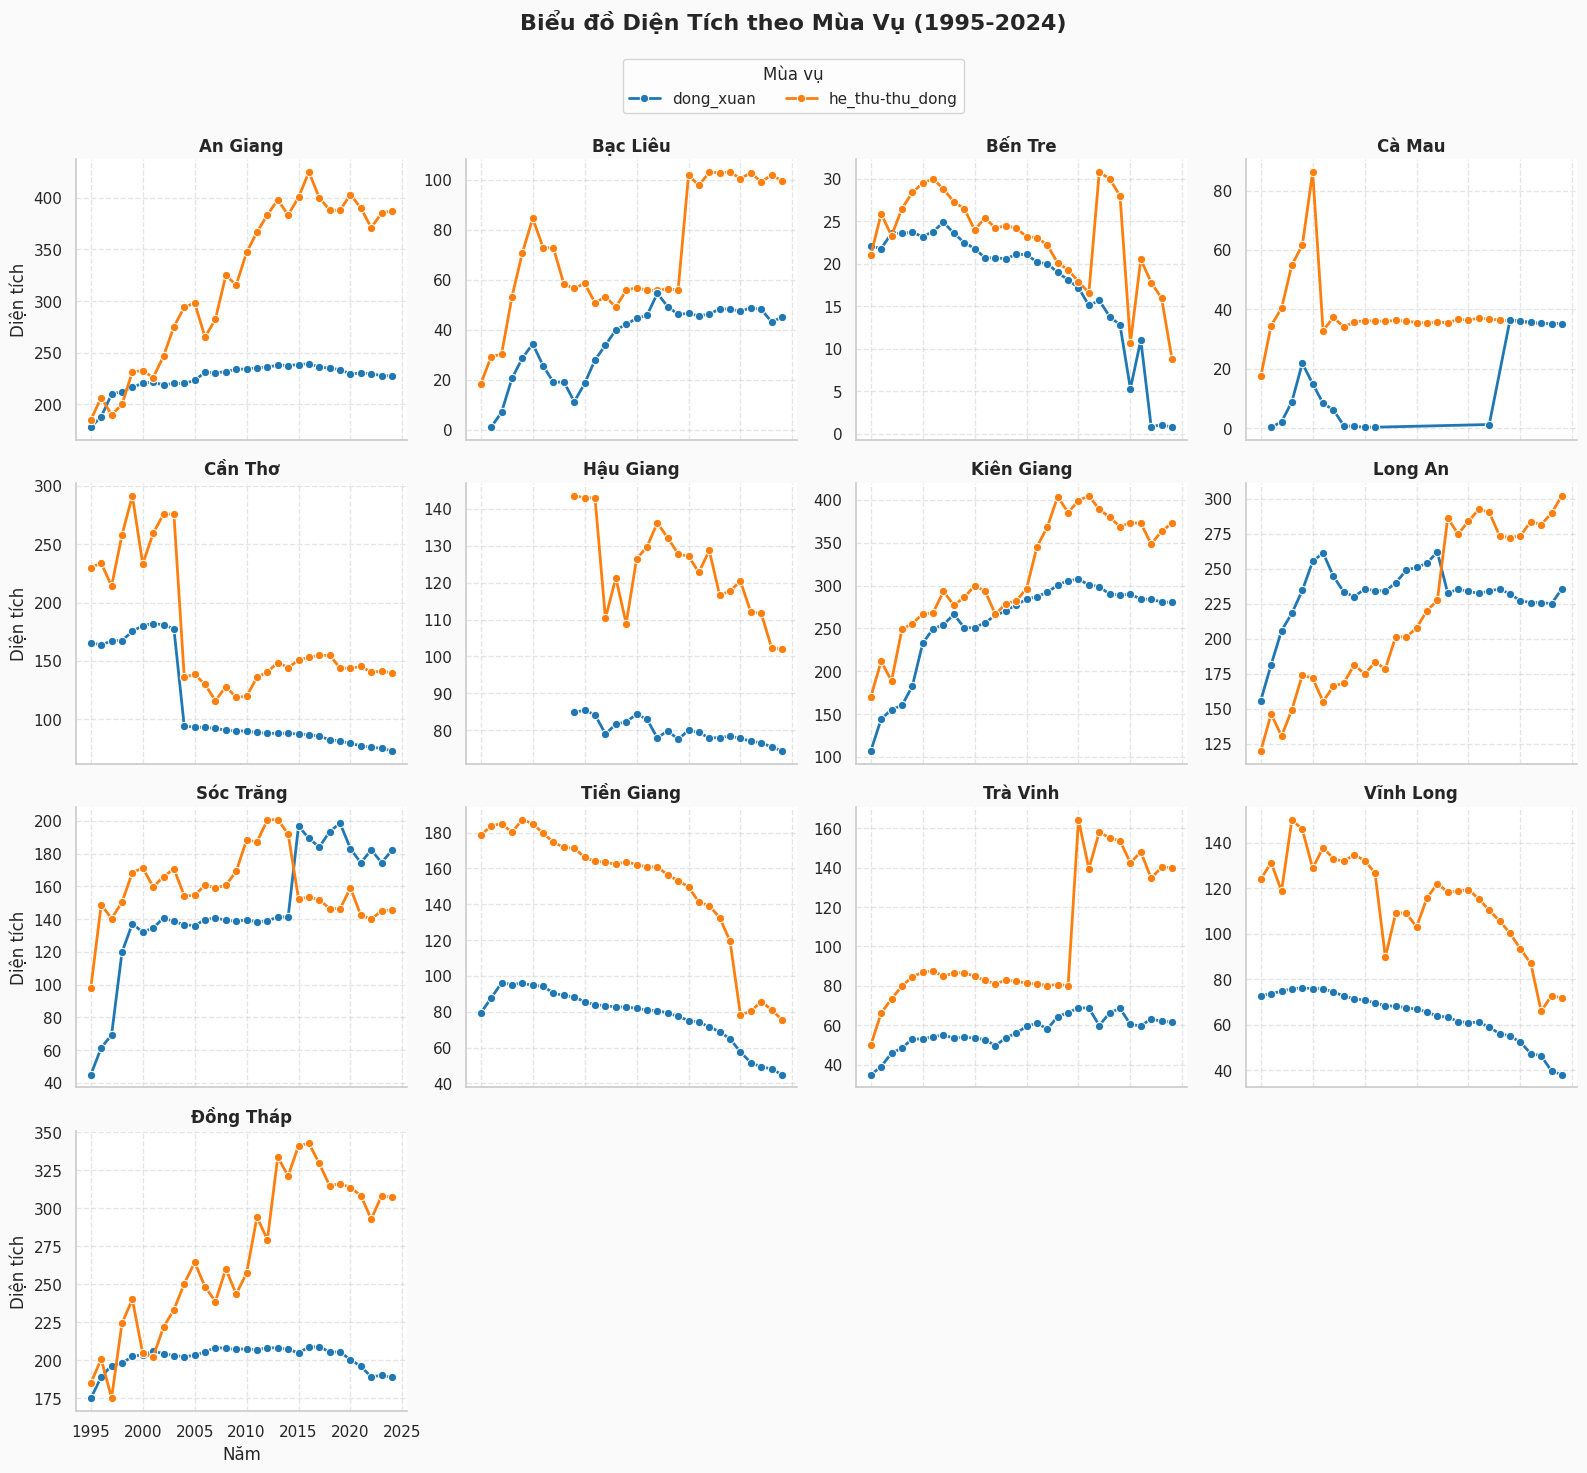

In [ ]:
df_clean = df.dropna(subset=['nam', 'tinh_thanh', 'dien_tich', 'san_luong', 'mua_vu']).copy()

# Lọc 2 mùa vụ
mua_vu_hop_le = ['dong_xuan', 'he_thu-thu_dong']
df_clean = df_clean[df_clean['mua_vu'].isin(mua_vu_hop_le)]
provinces = sorted(df_clean['tinh_thanh'].unique())

# 2. Khởi tạo lưới vẽ (4 cột)
cols = 4
rows = math.ceil(len(provinces) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(16, 3.5 * rows), sharex=True)
axes = axes.flatten()

palette = {'dong_xuan': '#1f77b4', 'he_thu-thu_dong': '#ff7f0e'}

# 3. Vẽ biểu đồ DIỆN TÍCH
for i, prov in enumerate(provinces):
    ax = axes[i]
    prov_data = df_clean[df_clean['tinh_thanh'] == prov]

    sns.lineplot(data=prov_data, x='nam', y='dien_tich', hue='mua_vu',
                 palette=palette, marker='o', linewidth=2, ax=ax)
    ax.set_title(f'{prov}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Diện tích' if i % cols == 0 else '')
    ax.set_xlabel('Năm' if i >= len(provinces) - cols else '')
    ax.grid(True, linestyle='--', alpha=0.5)

    # Ẩn legend từng ô nhỏ
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Xóa các ô thừa nếu có
for k in range(len(provinces), len(axes)):
    fig.delaxes(axes[k])

# Tạo Legend chung
handles, labels = ax.get_legend_handles_labels()
if labels and labels[0] == 'mua_vu':
    handles, labels = handles[1:], labels[1:]
fig.suptitle('Biểu đồ Diện Tích theo Mùa Vụ (1995-2024)', fontsize=16, fontweight='bold', y=1.05)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, title='Mùa vụ')

plt.tight_layout()
plt.show()

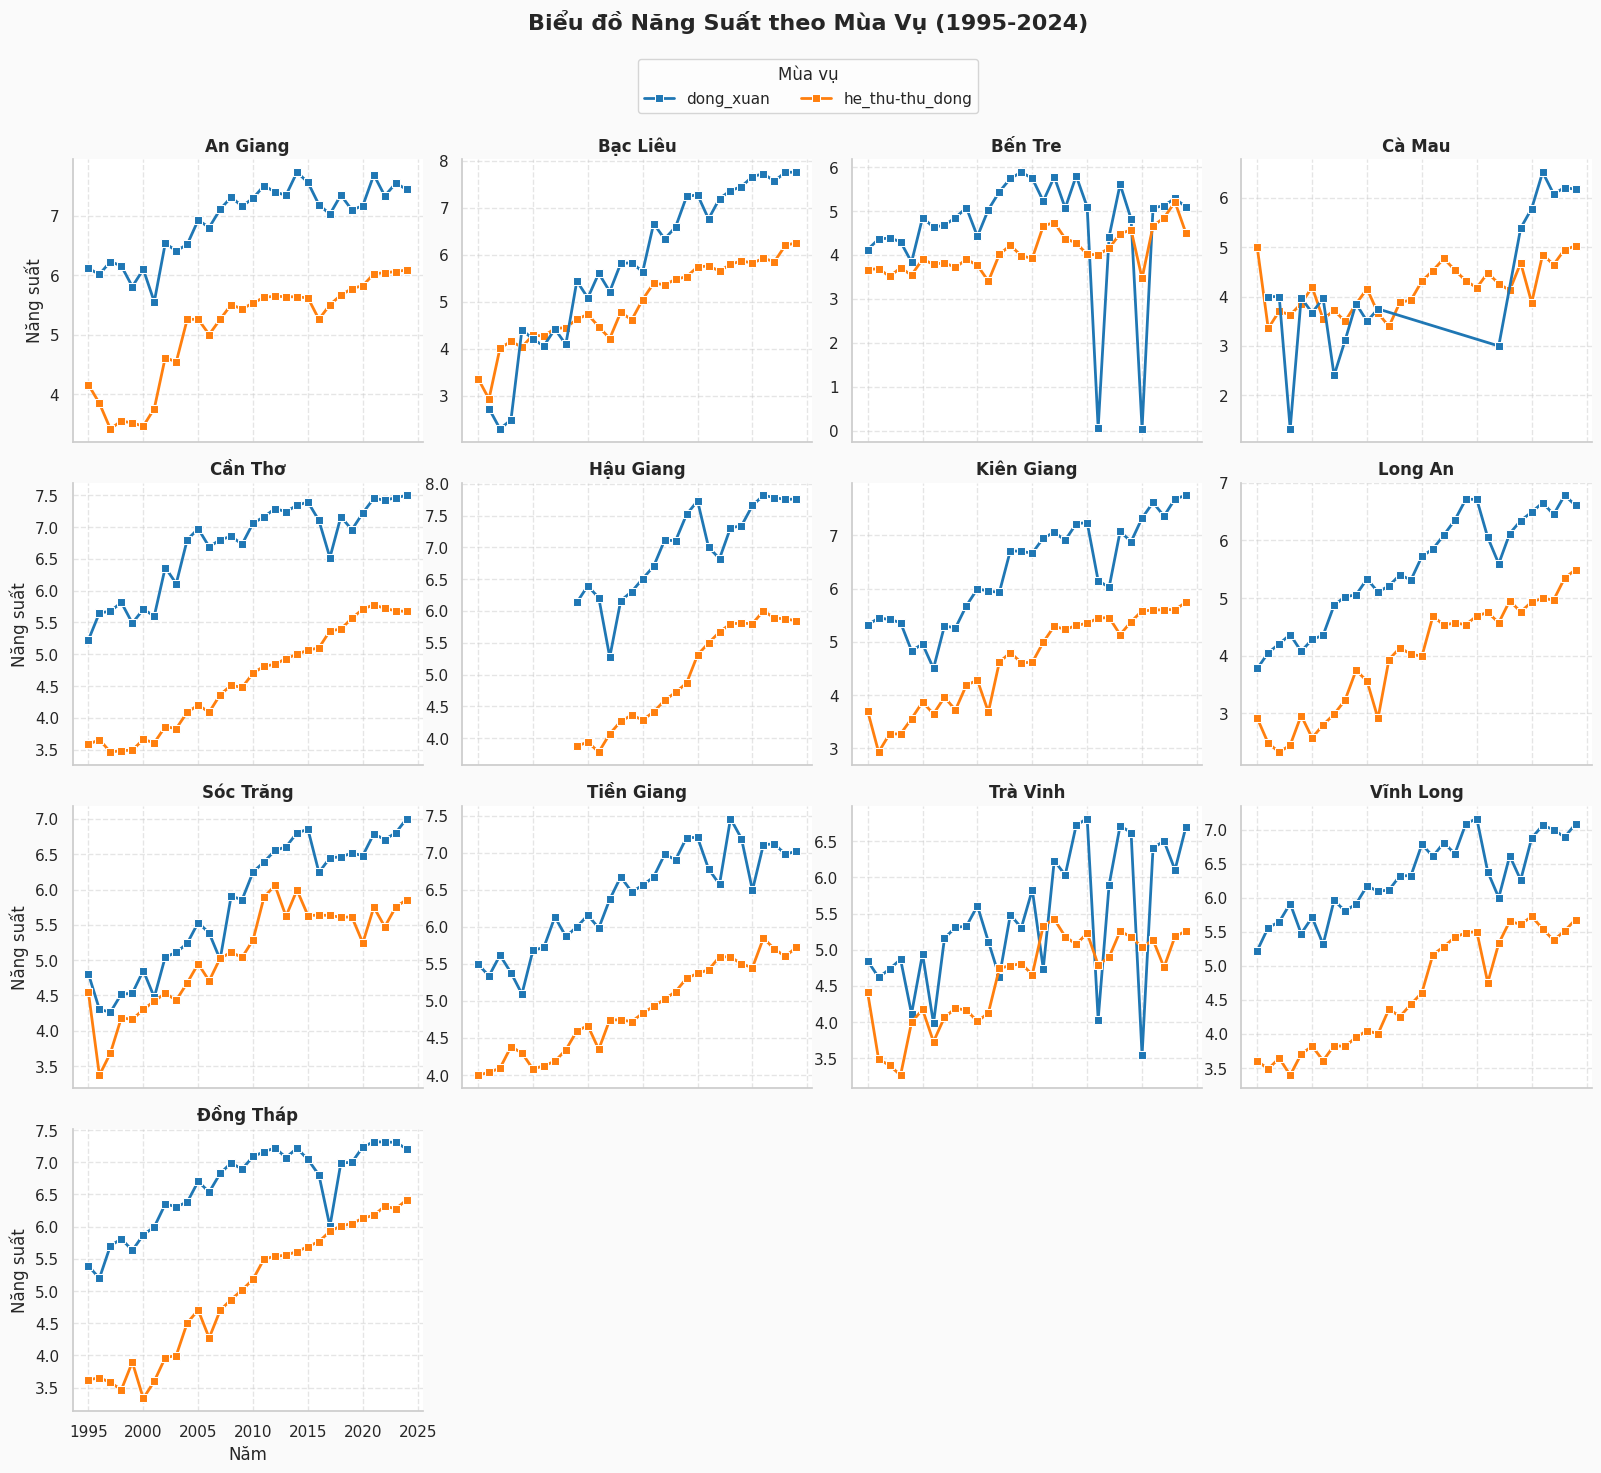

In [ ]:
df_clean = df.dropna(subset=['nam', 'tinh_thanh', 'dien_tich', 'san_luong', 'mua_vu']).copy()

# TÍNH NĂNG SUẤT
df_clean['nang_suat'] = df_clean['san_luong'] / df_clean['dien_tich']

# Lọc 2 mùa vụ
mua_vu_hop_le = ['dong_xuan', 'he_thu-thu_dong']
df_clean = df_clean[df_clean['mua_vu'].isin(mua_vu_hop_le)]
provinces = sorted(df_clean['tinh_thanh'].unique())

# 2. Khởi tạo lưới vẽ (4 cột)
cols = 4
rows = math.ceil(len(provinces) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(16, 3.5 * rows), sharex=True)
axes = axes.flatten()

palette = {'dong_xuan': '#1f77b4', 'he_thu-thu_dong': '#ff7f0e'}

# 3. Vẽ biểu đồ NĂNG SUẤT
for i, prov in enumerate(provinces):
    ax = axes[i]
    prov_data = df_clean[df_clean['tinh_thanh'] == prov]

    sns.lineplot(data=prov_data, x='nam', y='nang_suat', hue='mua_vu',
                 palette=palette, marker='s', linewidth=2, ax=ax)
    ax.set_title(f'{prov}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Năng suất' if i % cols == 0 else '')
    ax.set_xlabel('Năm' if i >= len(provinces) - cols else '')
    ax.grid(True, linestyle='--', alpha=0.5)

    # Ẩn legend từng ô nhỏ
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Xóa các ô thừa nếu có
for k in range(len(provinces), len(axes)):
    fig.delaxes(axes[k])

# Tạo Legend chung
handles, labels = ax.get_legend_handles_labels()
if labels and labels[0] == 'mua_vu':
    handles, labels = handles[1:], labels[1:]
fig.suptitle('Biểu đồ Năng Suất theo Mùa Vụ (1995-2024)', fontsize=16, fontweight='bold', y=1.05)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, title='Mùa vụ')

plt.tight_layout()
plt.show()

# Dashboard Tab 1 — Dataset overview / EDA

Cell dưới đây tạo file `dashboard_tab1_eda.py` để chạy dashboard bằng Streamlit.

Cách chạy trong terminal hoặc Kaggle/Colab terminal:

```bash
pip install streamlit plotly pandas numpy
streamlit run dashboard_tab1_eda.py
```

Dashboard hiện có đủ layout 3 tab, nhưng mới triển khai chi tiết Tab 1:
1. Overview
2. Data quality
3. Target & trend
4. Weather & correlation
5. FE readiness


In [ ]:
%%writefile dashboard_tab1_eda.py

# ============================================================
# Dashboard Tab 1: Dataset overview / EDA
# Dataset: Sản lượng lúa ĐBSCL 1995-2024
# Run:
#   pip install streamlit plotly pandas numpy
#   streamlit run dashboard_tab1_eda.py
# ============================================================

from __future__ import annotations

from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import plotly.express as px
import streamlit as st


RAW_FILE = "merged_dataset.csv"
FE_FILE = "merged_dataset_fe.csv"

TARGET_COLS = ["dien_tich", "san_luong"]
WEATHER_COLS = [
    "tổng số giờ nắng",
    "tổng lượng mưa",
    "độ ẩm trung bình",
    "nhiệt độ trung bình",
]
ID_COLS = ["nam", "tinh_thanh", "mua_vu"]

DATA_DICTIONARY = {
    "nam": "Năm quan sát.",
    "tinh_thanh": "Tỉnh/thành thuộc khu vực ĐBSCL.",
    "mua_vu": "Mùa vụ: đông xuân hoặc hè thu - thu đông.",
    "dien_tich": "Diện tích gieo trồng, đơn vị nghìn ha.",
    "san_luong": "Sản lượng lúa, đơn vị nghìn tấn.",
    "nang_suat": "Năng suất = san_luong / dien_tich, đơn vị tấn/ha.",
    "tổng số giờ nắng": "Tổng số giờ nắng theo mùa vụ/năm.",
    "tổng lượng mưa": "Tổng lượng mưa theo mùa vụ/năm.",
    "độ ẩm trung bình": "Độ ẩm trung bình theo mùa vụ/năm.",
    "nhiệt độ trung bình": "Nhiệt độ trung bình theo mùa vụ/năm.",
    "lat": "Vĩ độ tỉnh/thành trong bộ feature-engineered.",
    "lon": "Kinh độ tỉnh/thành trong bộ feature-engineered.",
    "mua_vu_encoded": "Mùa vụ đã được mã hóa số.",
    "nam_offset": "Năm được chuyển thành offset từ năm đầu tiên.",
    "gan_bien": "Biến nhị phân cho tỉnh gần biển.",
    "lag1/lag2": "Đặc trưng trễ 1 hoặc 2 bước theo chuỗi thời gian.",
    "roll2": "Đặc trưng trung bình trượt 2 bước.",
    "cross": "Đặc trưng tương tác/cross feature.",
}


def locate_file(filename: str) -> Path:
    """Find data files when the app is run from notebook folder or /mnt/data."""
    candidates = [
        Path.cwd() / filename,
        Path(__file__).resolve().parent / filename if "__file__" in globals() else Path.cwd() / filename,
        Path("/mnt/data") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Không tìm thấy {filename}. Hãy đặt file cùng thư mục với dashboard hoặc trong /mnt/data."
    )


@st.cache_data(show_spinner=False)
def load_raw_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = set(ID_COLS + TARGET_COLS + WEATHER_COLS)
    missing_cols = sorted(required - set(df.columns))
    if missing_cols:
        raise ValueError(f"Raw dataset thiếu các cột bắt buộc: {missing_cols}")

    df = df.copy()
    df["nang_suat"] = np.where(
        df["dien_tich"].notna() & (df["dien_tich"] != 0),
        df["san_luong"] / df["dien_tich"],
        np.nan,
    )
    df["target_missing"] = df[TARGET_COLS].isna().any(axis=1)
    return df


@st.cache_data(show_spinner=False)
def load_fe_data(path: str) -> pd.DataFrame:
    return pd.read_csv(path)


def format_int(value: float | int) -> str:
    if pd.isna(value):
        return "NA"
    return f"{int(value):,}".replace(",", ".")


def format_float(value: float, digits: int = 2) -> str:
    if pd.isna(value):
        return "NA"
    return f"{value:,.{digits}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    report = pd.DataFrame(
        {
            "column": df.columns,
            "missing_count": df.isna().sum().values,
            "missing_pct": (df.isna().mean().values * 100).round(2),
            "dtype": [str(dtype) for dtype in df.dtypes],
            "n_unique": [df[col].nunique(dropna=True) for col in df.columns],
        }
    )
    return report.sort_values(["missing_count", "column"], ascending=[False, True]).reset_index(drop=True)


def numeric_summary(df: pd.DataFrame, cols: Iterable[str]) -> pd.DataFrame:
    valid_cols = [col for col in cols if col in df.columns]
    if not valid_cols:
        return pd.DataFrame()
    summary = df[valid_cols].describe().T
    summary = summary[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
    return summary.round(3)


def add_download_button(df: pd.DataFrame, label: str, file_name: str) -> None:
    st.download_button(
        label=label,
        data=df.to_csv(index=False).encode("utf-8-sig"),
        file_name=file_name,
        mime="text/csv",
    )


def filter_panel(df: pd.DataFrame) -> pd.DataFrame:
    st.sidebar.header("Bộ lọc Tab 1")

    min_year = int(df["nam"].min())
    max_year = int(df["nam"].max())
    year_range = st.sidebar.slider(
        "Khoảng năm",
        min_value=min_year,
        max_value=max_year,
        value=(min_year, max_year),
        step=1,
    )

    provinces = sorted(df["tinh_thanh"].dropna().unique().tolist())
    selected_provinces = st.sidebar.multiselect(
        "Tỉnh/thành",
        options=provinces,
        default=provinces,
    )

    seasons = sorted(df["mua_vu"].dropna().unique().tolist())
    selected_seasons = st.sidebar.multiselect(
        "Mùa vụ",
        options=seasons,
        default=seasons,
    )

    filtered = df[
        df["nam"].between(year_range[0], year_range[1])
        & df["tinh_thanh"].isin(selected_provinces)
        & df["mua_vu"].isin(selected_seasons)
    ].copy()
    return filtered


def show_kpis(raw_df: pd.DataFrame, filtered_df: pd.DataFrame, fe_df: pd.DataFrame) -> None:
    complete_target_rows = int((~raw_df["target_missing"]).sum())
    completeness = complete_target_rows / len(raw_df) * 100 if len(raw_df) else 0

    c1, c2, c3, c4, c5 = st.columns(5)
    c1.metric("Raw rows", format_int(len(raw_df)))
    c2.metric("Filtered rows", format_int(len(filtered_df)))
    c3.metric("Tỉnh/thành", format_int(raw_df["tinh_thanh"].nunique()))
    c4.metric("Giai đoạn", f"{int(raw_df['nam'].min())}–{int(raw_df['nam'].max())}")
    c5.metric("Target completeness", f"{format_float(completeness, 1)}%")

    c6, c7, c8, c9, c10 = st.columns(5)
    c6.metric("Mùa vụ", format_int(raw_df["mua_vu"].nunique()))
    c7.metric("Thiếu target", format_int(int(raw_df["target_missing"].sum())))
    c8.metric("FE rows", format_int(len(fe_df)))
    c9.metric("FE columns", format_int(fe_df.shape[1]))
    c10.metric("Duplicate keys", format_int(raw_df.duplicated(subset=ID_COLS).sum()))


def overview_section(raw_df: pd.DataFrame, filtered_df: pd.DataFrame, fe_df: pd.DataFrame) -> None:
    st.subheader("Tổng quan dữ liệu")
    show_kpis(raw_df, filtered_df, fe_df)

    st.markdown(
        """
        **Mục tiêu của Tab 1** là kiểm tra nhanh dữ liệu trước khi sang mô hình:
        dữ liệu có đủ theo tỉnh/năm/mùa vụ không, target `nang_suat` phân bố thế nào,
        biến thời tiết có quan hệ gì với năng suất, và bộ feature-engineered đã sẵn sàng cho modeling chưa.
        """
    )

    left, right = st.columns([1.2, 1])
    with left:
        st.markdown("**Preview dữ liệu raw sau khi tính `nang_suat`**")
        st.dataframe(filtered_df.head(50), use_container_width=True, hide_index=True)
        add_download_button(filtered_df, "Tải dữ liệu sau filter", "filtered_raw_eda.csv")

    with right:
        st.markdown("**Data dictionary**")
        dictionary_df = pd.DataFrame(
            [{"column/pattern": key, "meaning": value} for key, value in DATA_DICTIONARY.items()]
        )
        st.dataframe(dictionary_df, use_container_width=True, hide_index=True)

    st.markdown("**Số dòng theo năm và mùa vụ**")
    season_count = (
        filtered_df.groupby(["nam", "mua_vu"], as_index=False)
        .size()
        .rename(columns={"size": "n_rows"})
    )
    if season_count.empty:
        st.warning("Không có dữ liệu sau bộ lọc hiện tại.")
    else:
        fig = px.bar(
            season_count,
            x="nam",
            y="n_rows",
            color="mua_vu",
            barmode="group",
            labels={"nam": "Năm", "n_rows": "Số dòng", "mua_vu": "Mùa vụ"},
            title="Coverage theo năm và mùa vụ",
        )
        st.plotly_chart(fig, use_container_width=True)


def data_quality_section(raw_df: pd.DataFrame, filtered_df: pd.DataFrame, fe_df: pd.DataFrame) -> None:
    st.subheader("Data quality & missing values")

    c1, c2 = st.columns(2)
    with c1:
        st.markdown("**Missing report - raw dataset**")
        st.dataframe(missing_report(raw_df), use_container_width=True, hide_index=True)

    with c2:
        st.markdown("**Missing report - feature-engineered dataset**")
        st.dataframe(missing_report(fe_df), use_container_width=True, hide_index=True)

    st.markdown("**Missing target theo tỉnh và năm**")
    missing_pivot = (
        raw_df.assign(target_missing=raw_df[TARGET_COLS].isna().any(axis=1).astype(int))
        .pivot_table(
            index="tinh_thanh",
            columns="nam",
            values="target_missing",
            aggfunc="sum",
            fill_value=0,
        )
    )
    if missing_pivot.empty:
        st.info("Không có missing target.")
    else:
        fig = px.imshow(
            missing_pivot,
            aspect="auto",
            labels=dict(x="Năm", y="Tỉnh/thành", color="Số dòng thiếu"),
            title="Heatmap thiếu `dien_tich` hoặc `san_luong`",
        )
        fig.update_xaxes(type="category")
        st.plotly_chart(fig, use_container_width=True)

    st.markdown("**Thiếu target theo tỉnh/thành**")
    missing_by_province = (
        raw_df.groupby("tinh_thanh")[TARGET_COLS]
        .apply(lambda frame: frame.isna().sum())
        .reset_index()
        .sort_values(TARGET_COLS, ascending=False)
    )
    st.dataframe(missing_by_province, use_container_width=True, hide_index=True)

    st.markdown("**Thống kê numeric sau filter**")
    summary_cols = ["nang_suat", "dien_tich", "san_luong"] + WEATHER_COLS
    st.dataframe(numeric_summary(filtered_df, summary_cols), use_container_width=True)


def target_trend_section(filtered_df: pd.DataFrame) -> None:
    st.subheader("Target, diện tích, sản lượng và xu hướng")

    if filtered_df.empty:
        st.warning("Không có dữ liệu sau bộ lọc hiện tại.")
        return

    valid_target = filtered_df.dropna(subset=["nang_suat", "dien_tich", "san_luong"]).copy()
    if valid_target.empty:
        st.warning("Không có dòng đủ `dien_tich` và `san_luong` để tính năng suất.")
        return

    kpi_cols = st.columns(4)
    kpi_cols[0].metric("Năng suất TB", f"{format_float(valid_target['nang_suat'].mean(), 2)} tấn/ha")
    kpi_cols[1].metric("Năng suất min", f"{format_float(valid_target['nang_suat'].min(), 2)}")
    kpi_cols[2].metric("Năng suất max", f"{format_float(valid_target['nang_suat'].max(), 2)}")
    kpi_cols[3].metric("Dòng đủ target", format_int(len(valid_target)))

    trend = (
        valid_target.groupby(["nam", "mua_vu"], as_index=False)
        .agg(
            nang_suat_mean=("nang_suat", "mean"),
            dien_tich_sum=("dien_tich", "sum"),
            san_luong_sum=("san_luong", "sum"),
        )
    )

    metric_to_plot = st.radio(
        "Chọn biến xu hướng",
        options=[
            "nang_suat_mean",
            "dien_tich_sum",
            "san_luong_sum",
        ],
        format_func=lambda x: {
            "nang_suat_mean": "Năng suất trung bình",
            "dien_tich_sum": "Tổng diện tích",
            "san_luong_sum": "Tổng sản lượng",
        }[x],
        horizontal=True,
    )

    fig = px.line(
        trend,
        x="nam",
        y=metric_to_plot,
        color="mua_vu",
        markers=True,
        labels={
            "nam": "Năm",
            metric_to_plot: {
                "nang_suat_mean": "Năng suất TB (tấn/ha)",
                "dien_tich_sum": "Tổng diện tích (nghìn ha)",
                "san_luong_sum": "Tổng sản lượng (nghìn tấn)",
            }[metric_to_plot],
            "mua_vu": "Mùa vụ",
        },
        title="Xu hướng theo năm và mùa vụ",
    )
    st.plotly_chart(fig, use_container_width=True)

    left, right = st.columns(2)
    with left:
        fig = px.box(
            valid_target,
            x="tinh_thanh",
            y="nang_suat",
            color="mua_vu",
            points="outliers",
            labels={"tinh_thanh": "Tỉnh/thành", "nang_suat": "Năng suất (tấn/ha)", "mua_vu": "Mùa vụ"},
            title="Phân bố năng suất theo tỉnh và mùa vụ",
        )
        fig.update_xaxes(tickangle=-45)
        st.plotly_chart(fig, use_container_width=True)

    with right:
        province_summary = (
            valid_target.groupby("tinh_thanh", as_index=False)
            .agg(
                nang_suat_mean=("nang_suat", "mean"),
                nang_suat_std=("nang_suat", "std"),
                dien_tich_mean=("dien_tich", "mean"),
                san_luong_mean=("san_luong", "mean"),
                n_rows=("nang_suat", "size"),
            )
            .sort_values("nang_suat_mean", ascending=False)
        )
        fig = px.bar(
            province_summary,
            x="tinh_thanh",
            y="nang_suat_mean",
            error_y="nang_suat_std",
            labels={"tinh_thanh": "Tỉnh/thành", "nang_suat_mean": "Năng suất TB (tấn/ha)"},
            title="Năng suất trung bình theo tỉnh",
        )
        fig.update_xaxes(tickangle=-45)
        st.plotly_chart(fig, use_container_width=True)

    st.markdown("**Bảng tổng hợp theo tỉnh**")
    st.dataframe(province_summary.round(3), use_container_width=True, hide_index=True)


def weather_correlation_section(filtered_df: pd.DataFrame) -> None:
    st.subheader("Thời tiết và tương quan")

    if filtered_df.empty:
        st.warning("Không có dữ liệu sau bộ lọc hiện tại.")
        return

    numeric_cols = ["nang_suat", "dien_tich", "san_luong"] + WEATHER_COLS
    data = filtered_df[numeric_cols + ["mua_vu", "tinh_thanh", "nam"]].dropna(subset=["nang_suat"])
    if data.empty:
        st.warning("Không có dữ liệu đủ để phân tích tương quan.")
        return

    corr_data = data[numeric_cols].dropna()
    left, right = st.columns([1, 1])

    with left:
        if len(corr_data) >= 2:
            corr = corr_data.corr(method="pearson").round(3)
            fig = px.imshow(
                corr,
                text_auto=True,
                aspect="auto",
                labels=dict(color="Pearson r"),
                title="Ma trận tương quan Pearson",
            )
            st.plotly_chart(fig, use_container_width=True)
        else:
            st.info("Cần ít nhất 2 dòng đầy đủ để tính tương quan.")

    with right:
        corr_with_target = (
            corr_data.corr(method="pearson")["nang_suat"]
            .drop("nang_suat")
            .sort_values(key=lambda s: s.abs(), ascending=False)
            .reset_index()
            .rename(columns={"index": "variable", "nang_suat": "corr_with_nang_suat"})
        )
        st.markdown("**Tương quan với `nang_suat`**")
        st.dataframe(corr_with_target.round(3), use_container_width=True, hide_index=True)

    selected_weather = st.selectbox(
        "Chọn biến thời tiết để xem scatter với năng suất",
        options=WEATHER_COLS,
    )
    fig = px.scatter(
        data.dropna(subset=[selected_weather, "nang_suat"]),
        x=selected_weather,
        y="nang_suat",
        color="mua_vu",
        hover_data=["nam", "tinh_thanh", "dien_tich", "san_luong"],
        labels={selected_weather: selected_weather, "nang_suat": "Năng suất (tấn/ha)", "mua_vu": "Mùa vụ"},
        title=f"Năng suất vs {selected_weather}",
    )
    st.plotly_chart(fig, use_container_width=True)

    weather_summary = (
        filtered_df.groupby("mua_vu")[WEATHER_COLS]
        .agg(["mean", "std", "min", "max"])
        .round(2)
    )
    st.markdown("**Thống kê thời tiết theo mùa vụ**")
    st.dataframe(weather_summary, use_container_width=True)


def feature_readiness_section(fe_df: pd.DataFrame) -> None:
    st.subheader("Feature-engineered dataset readiness")

    st.markdown(
        """
        Phần này kiểm tra nhanh bộ `merged_dataset_fe.csv` trước khi dùng cho modeling:
        số feature, missing do lag/rolling, và quan hệ giữa các feature với target `nang_suat`.
        """
    )

    numeric_cols = fe_df.select_dtypes(include=[np.number]).columns.tolist()
    target = "nang_suat" if "nang_suat" in fe_df.columns else None
    feature_cols = [col for col in numeric_cols if col != target]

    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Rows", format_int(len(fe_df)))
    c2.metric("Columns", format_int(fe_df.shape[1]))
    c3.metric("Numeric features", format_int(len(feature_cols)))
    c4.metric("Rows with any missing", format_int(int(fe_df.isna().any(axis=1).sum())))

    left, right = st.columns([1, 1])
    with left:
        st.markdown("**Missing theo feature**")
        st.dataframe(missing_report(fe_df), use_container_width=True, hide_index=True)

    with right:
        st.markdown("**Preview FE dataset**")
        st.dataframe(fe_df.head(50), use_container_width=True, hide_index=True)

    if target:
        corr = (
            fe_df[numeric_cols]
            .corr(method="pearson")[target]
            .drop(target)
            .dropna()
            .sort_values(key=lambda s: s.abs(), ascending=False)
            .reset_index()
            .rename(columns={"index": "feature", target: "corr_with_target"})
        )
        st.markdown("**Top feature tương quan với `nang_suat`**")
        st.dataframe(corr.head(20).round(3), use_container_width=True, hide_index=True)

        top_features = corr.head(12)
        if not top_features.empty:
            fig = px.bar(
                top_features,
                x="corr_with_target",
                y="feature",
                orientation="h",
                labels={"corr_with_target": "Pearson r với năng suất", "feature": "Feature"},
                title="Top 12 feature tương quan mạnh nhất với target",
            )
            fig.update_layout(yaxis={"categoryorder": "total ascending"})
            st.plotly_chart(fig, use_container_width=True)

    lag_cols = [col for col in fe_df.columns if any(token in col for token in ["lag", "roll", "cross"])]
    if lag_cols:
        st.markdown("**Các feature lag/rolling/cross**")
        st.dataframe(numeric_summary(fe_df, lag_cols), use_container_width=True)


def main() -> None:
    st.set_page_config(
        page_title="Dashboard lúa ĐBSCL",
        page_icon="🌾",
        layout="wide",
    )

    st.title("🌾 Dashboard sản lượng và năng suất lúa ĐBSCL")
    st.caption("Tab 1: Dataset overview / EDA. Tab 2 và Tab 3 được để sẵn layout cho các bước sau.")

    try:
        raw_path = locate_file(RAW_FILE)
        fe_path = locate_file(FE_FILE)
        raw_df = load_raw_data(str(raw_path))
        fe_df = load_fe_data(str(fe_path))
    except Exception as exc:
        st.error(f"Lỗi khi đọc dữ liệu: {exc}")
        st.stop()

    filtered_df = filter_panel(raw_df)

    tab_eda, tab_model, tab_error = st.tabs(
        [
            "1. Dataset overview / EDA",
            "2. Model Performance",
            "3. Error explorer",
        ]
    )

    with tab_eda:
        overview, quality, target, weather, features = st.tabs(
            [
                "Overview",
                "Data quality",
                "Target & trend",
                "Weather & correlation",
                "FE readiness",
            ]
        )

        with overview:
            overview_section(raw_df, filtered_df, fe_df)

        with quality:
            data_quality_section(raw_df, filtered_df, fe_df)

        with target:
            target_trend_section(filtered_df)

        with weather:
            weather_correlation_section(filtered_df)

        with features:
            feature_readiness_section(fe_df)

    with tab_model:
        st.info("Tab 2 sẽ dùng cho Model Performance sau khi có prediction, metrics hoặc experiment log.")

    with tab_error:
        st.info("Tab 3 sẽ dùng cho Error explorer / residual check sau khi có residual hoặc file prediction.")


if __name__ == "__main__":
    main()


Sau khi chạy cell tạo file, chạy lệnh dưới trong terminal:

```bash
streamlit run dashboard_tab1_eda.py
```

Lưu ý: đặt `merged_dataset.csv` và `merged_dataset_fe.csv` cùng thư mục với file dashboard.
